# Exercise 2 — Flood impact for one storm of an ensemble

The dashboard for this exercise has a **Storm** slider. Moving it redraws a flood
depth map and recomputes a table of how many buildings, people and roads are
affected. This notebook derives that table from scratch, so you can see exactly
what the dashboard is doing.

The question being answered is:

> **In storm 150, how deep is the water on each building and road?**

Depth is a physical quantity, so the answer needs no reference to a threshold —
this is worth contrasting with Exercise 3, which works from *probabilities* and
therefore needs one.

**Workflow**

1. Open the storm ensemble and look at one storm
2. Load the buildings and roads
3. Discover that both sit on the *same grid* — the fact that makes this easy
4. Sample the deepest water on each building's own footprint
5. Group into depth bands and build the impact table
6. See how impact grows across the ensemble

Everything is read from a public S3 bucket. Nothing is stored locally.

In [1]:
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize

%matplotlib inline

BUCKET = "https://cog-s3-test-401506828094-us-east-1-an.s3.us-east-1.amazonaws.com"
STORE = f"{BUCKET}/floodmaps_test"                              # the storm ensemble
FEATURES = f"{BUCKET}/Guatemala_IBF/impact_features.geojson"     # buildings + roads

print("ready")

ready


## 1. The storm ensemble

The flood maps live in a **Zarr store** — think of it as an array split into many
small files, so you can read one slice without downloading the whole thing. The
`depth` array here is about 108 MB in total; we only ever want one storm at a
time.

The store carries its own metadata. Read that first: it tells you where you are,
what units you are in, and — importantly — what *not* to trust.

In [2]:
import zarr
from zarr.storage import FsspecStore

group = zarr.open_group(FsspecStore.from_url(STORE), mode="r")
attrs = dict(group.attrs)

for key, value in attrs.items():
    print(f"{key:22} {value}")

crs                    EPSG:3857
transform              [5.0, 0.0, -10079319.926, 0.0, -5.0, 1630785.079]
extent_threshold_m     0.05
source_nodata          -3.4028234663852886e+38
magnitude_source       placeholder_rank_by_flooded_area_25_300mm
n_storms               200
grid_shape             [424, 319]
site                   SantaInesPetapa
country                Guatemala
library_source         RainyDay x hydraulic model, 200 samples
note                   magnitudes are placeholders; run attach_magnitudes() with real RainyDay 24-h totals


Three things to take from that:

- **`site` / `country`** — Santa Inés Petapa, Guatemala.
- **`extent_threshold_m: 0.05`** — the model does not consider a cell wet below
  5 cm. We will reuse that number rather than inventing our own.
- **`note`** — *"magnitudes are placeholders"*. The storms were sorted by flooded
  area and rainfall magnitudes assigned to the ranks. So a storm's "mm" figure is
  a label, **not measured rainfall**. Plotting impact against it would look like a
  finding and would actually be circular. We will plot against storm *index*
  instead.

`depth` is in **metres**, and `transform` + `crs` tell us where each cell sits.

In [3]:
depth = group["depth"]
print(f"depth array: shape {depth.shape}  dtype {depth.dtype}  chunks {depth.chunks}")
print(f"  -> {depth.nbytes / 1e6:.0f} MB in total, "
      f"{np.prod(depth.chunks) * 4 / 1e3:.0f} KB per storm")

STORM = 150                      # try changing this: 2 is nearly dry, 199 is the worst
one_storm = np.asarray(depth[STORM], dtype="float32")
one_storm = np.where(np.isfinite(one_storm) & (one_storm > 0), one_storm, 0.0)

wet = one_storm[one_storm >= attrs["extent_threshold_m"]]
print(f"\nstorm {STORM}: {wet.size:,} wet cells, "
      f"max {one_storm.max():.2f} m, mean where wet {wet.mean():.2f} m")

depth array: shape (200, 424, 319)  dtype float32  chunks (1, 424, 319)
  -> 108 MB in total, 541 KB per storm



storm 150: 36,010 wet cells, max 13.32 m, mean where wet 3.11 m


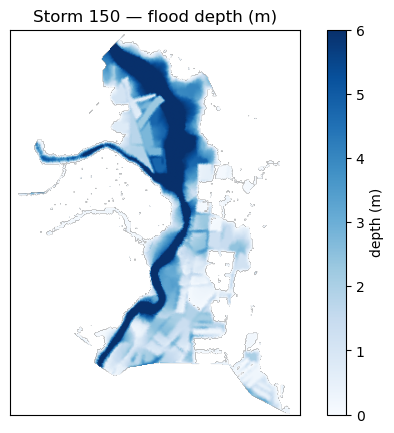

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
shown = np.where(one_storm >= attrs["extent_threshold_m"], one_storm, np.nan)
im = ax.imshow(shown, cmap="Blues", vmin=0, vmax=6)
ax.set_title(f"Storm {STORM} — flood depth (m)")
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, label="depth (m)")
plt.show()

## 2. The ensemble summary

Per-storm statistics are cheap for *one* storm but expensive for all 200 — that
means reading the whole 108 MB array. So the summary is **precomputed** once and
published next to the store as a small CSV. The dashboard reads this, not the
arrays.

This is a pattern worth copying: if a dashboard needs a number derived from a
large dataset, compute it once offline.

In [5]:
stats = pd.read_csv(f"{STORE}/ensemble_stats.csv")
print(f"{len(stats)} rows — one per storm\n")
stats.head(3)

200 rows — one per storm



,storm_index,storm_id,magnitude_mm,flooded_px,area_km2,pct_domain,max_depth_m,mean_wet_depth_m
0,0,sample_0003,25.00,0,0.0000,0.00,0.000,0.000
1,1,sample_0004,26.38,0,0.0000,0.00,0.000,0.000
2,2,sample_0002,27.76,1667,0.0417,1.23,2.669,1.075


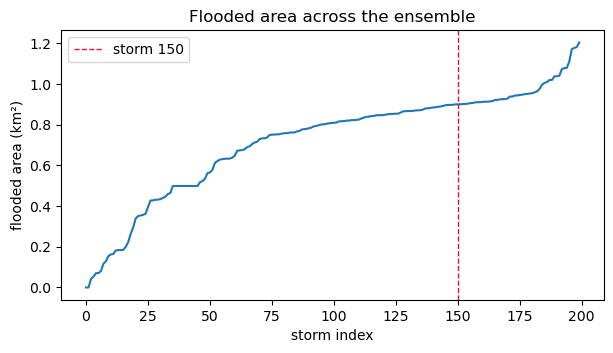

strictly non-decreasing: True


In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(stats.storm_index, stats.area_km2, lw=1.5)
ax.axvline(STORM, color="crimson", ls="--", lw=1, label=f"storm {STORM}")
ax.set_xlabel("storm index"); ax.set_ylabel("flooded area (km²)")
ax.set_title("Flooded area across the ensemble")
ax.legend(); plt.show()

increasing = bool((stats.area_km2.diff().dropna() >= 0).all())
print(f"strictly non-decreasing: {increasing}")

That curve rises monotonically because the ensemble was **sorted by flooded
area**. The slider therefore walks *severity*, not time — there is no time
dimension in this dataset at all. Naming the slider "Storm" rather than "Forecast
Step" matters for exactly this reason.

Note also that storms 0 and 1 are completely dry: their chunks were never written,
because Zarr omits chunks that are entirely fill-value. That is why the dashboard's
slider starts at 2.

## 3. The buildings and roads

The exposure data is a slimmed-down copy of an IBF geopackage: only the features
that carry flood information, with geometry kept so we can map them.

In [7]:
features = gpd.read_file(FEATURES)
print(f"{len(features):,} features  |  CRS {features.crs}")
print(features.tipo.value_counts().to_string())
print()
features[["tipo", "poblacion", "area_m2", "longitud_m"]].head(3)

5,147 features  |  CRS EPSG:32615
tipo
edificio     4689
carretera     458



,tipo,poblacion,area_m2,longitud_m
0,edificio,6.22,178.0,0.0
1,edificio,5.08,145.4,0.0
2,edificio,4.44,127.0,0.0


`poblacion` is the **per-building** population estimate. A trap worth knowing
about: the source geopackage also has a `Población` column that repeats the whole
*municipality* total on every building. Summing that one overstates exposure by
four orders of magnitude. Always check whether a population field is a total or a
disaggregation.

## 4. The fact that makes this easy: one shared grid

Two datasets from different sources rarely line up. These do — exactly. Compare
the ensemble's grid with the probability rasters used in Exercise 3:

In [8]:
zarr_transform = rasterio.Affine(*attrs["transform"])
rows, cols = attrs["grid_shape"]

with rasterio.open(f"{BUCKET}/PBI_Actividad_2/prob_7p62.tif") as ref:
    print(f"{'':22}{'ensemble (Zarr)':<34}{'probability raster'}")
    print(f"{'CRS':22}{attrs['crs']:<34}{ref.crs}")
    print(f"{'shape':22}{str((rows, cols)):<34}{ref.shape}")
    print(f"{'cell size':22}{zarr_transform.a:<34}{ref.transform.a}")
    print(f"{'origin':22}{str((zarr_transform.c, zarr_transform.f)):<34}"
          f"{(ref.transform.c, ref.transform.f)}")
    same = (str(ref.crs) == attrs["crs"] and ref.shape == (rows, cols)
            and np.allclose(tuple(ref.transform)[:6], tuple(zarr_transform)[:6]))
print(f"\nidentical grid: {same}")

                      ensemble (Zarr)                   probability raster
CRS                   EPSG:3857                         EPSG:3857
shape                 (424, 319)                        (424, 319)
cell size             5.0                               5.0
origin                (-10079319.926, 1630785.079)      (-10079319.926, 1630785.079)

identical grid: True


Same CRS, same shape, same 5 m cells, same origin. So we can sample the flood
depth onto the buildings with **no reprojection and no resampling** — every
building sits over a known set of cells.

The features arrive in a different CRS, so reproject those (cheap — it is vector
data) rather than touching the raster.

In [9]:
features = features.to_crs(attrs["crs"])
print(f"features now in {features.crs}")
print(f"bounds {[round(v) for v in features.total_bounds]}")
print(f"grid   {[round(v) for v in rasterio.transform.array_bounds(rows, cols, zarr_transform)]}")

features now in EPSG:3857
bounds [-10082636, 1628003, -10075788, 1631747]
grid   [-10079320, 1628665, -10077725, 1630785]


## 5. Sampling depth onto each feature

We want, for each building, **the deepest water anywhere on its footprint**. That
is the conservative reading, and it matches how the IBF probabilities in Exercise 3
were sampled, so the two products stay comparable.

Doing this one feature at a time would be slow. Instead:

1. **Rasterise once** — burn each feature's *id* into a grid. This does not depend
   on the storm, so it is paid once and reused for all 200.
2. For each storm, take the maximum depth per id with `np.maximum.at`, which is a
   single pass over the cells.

`all_touched=True` means a cell counts if the feature touches it at all, not only
if the cell centre falls inside — important when buildings are only a few cells
across.

In [10]:
ids = rasterize(
    ((geom, i + 1) for i, geom in enumerate(features.geometry)),   # 0 means "no feature"
    out_shape=(rows, cols),
    transform=zarr_transform,
    fill=0,
    all_touched=True,
    dtype="int32",
)

in_domain = np.unique(ids)
in_domain = in_domain[in_domain > 0]
print(f"{int((ids > 0).sum()):,} of {ids.size:,} cells are covered by a feature")
print(f"{len(in_domain):,} of {len(features):,} features land on the grid "
      f"({100 * len(in_domain) / len(features):.1f}%)")

41,808 of 135,256 cells are covered by a feature
5,029 of 5,147 features land on the grid (97.7%)


**118 features fall outside the model domain.** The domain is only 3.38 km²
and the geopackage extends beyond it, so those features can never be reported as
affected — whatever the storm. When you quote a percentage, say "of 5,029 in the
model domain", not "of 5,147", or you quietly understate the impact.

In [11]:
def feature_max_depth(storm_index):
    """Deepest water over each feature's own footprint, in metres."""
    layer = np.asarray(depth[storm_index], dtype="float32")
    # The store's nodata is a large negative float. Anything non-finite or
    # negative is "no water", not a depth.
    layer = np.where(np.isfinite(layer) & (layer > 0), layer, 0.0)

    per_feature = np.zeros(len(features) + 1, dtype="float32")
    np.maximum.at(per_feature, ids.ravel(), layer.ravel())
    return per_feature[1:]          # drop index 0: every cell with no feature

depths = feature_max_depth(STORM)
print(f"storm {STORM}: {int((depths >= 0.05).sum()):,} features touched by water")
print(f"  deepest single feature: {depths.max():.2f} m")

storm 150: 2,792 features touched by water
  deepest single feature: 13.16 m


## 6. Depth bands

Now group the depths into bands. These are round numbers chosen so each one reads
without a legend — roughly ankle, knee, and above head height. The 0.05 m floor is
the store's own `extent_threshold_m`, not a number we invented.

Assign in **ascending** order and let later assignments win, so each feature ends
up in the deepest band it reaches.

In [12]:
DEPTH_BANDS = [          # (class value, colour, lower bound in metres)
    (1, "green", 0.05),
    (2, "yellow", 0.30),
    (3, "red", 1.00),
    (4, "purple", 2.00),
]
BAND_LABEL = {1: "0.05 - 0.3 m", 2: "0.3 - 1 m", 3: "1 - 2 m", 4: "2 m or more"}


def classify_depth(values):
    band = np.zeros(len(values), dtype="uint8")     # 0 = dry
    for value, _colour, floor in DEPTH_BANDS:
        band[values >= floor] = value               # deepest band wins
    return band


features["depth_m"] = depths
features["band"] = classify_depth(depths)
features["level"] = features.band.map(BAND_LABEL)

features.band.value_counts().sort_index().rename(BAND_LABEL).rename_axis("band")

band
0               2355
0.05 - 0.3 m     329
0.3 - 1 m        411
1 - 2 m          618
2 m or more     1434
Name: count, dtype: int64

> ⚠️ **Classify before you round.** If you round the depths to 2 decimals first
> and *then* classify, features sitting at 0.0455 m round up to 0.05 and get
> promoted into the wet band. That is a display concern silently changing the
> answer — it moved 14 features when we hit it for real. Round only what you print.

## 7. The impact table

This is what the dashboard shows. Deepest band first, so the worst case is read
first, with a total across every affected feature.

In [13]:
TOTAL_POPULATION = 290_868      # every building in the geopackage, for a share


def impact_row(name, group):
    buildings = group[group.tipo == "edificio"]
    return {
        "Depth": name,
        "Buildings": f"{len(buildings):,}",
        "Population": f"{group.poblacion.sum():,.0f}",
        "Area (m²)": f"{group.area_m2.sum():,.0f}",
        "Roads (km)": f"{group.longitud_m.sum() / 1000:,.1f}",
        "% of population": f"{100 * group.poblacion.sum() / TOTAL_POPULATION:.2f}%",
    }


affected = features[features.band > 0]
# Note: not `rows` -- that name already holds the grid height from section 4.
table_rows = [impact_row(BAND_LABEL[v], affected[affected.band == v])
              for v, _c, _f in reversed(DEPTH_BANDS)]
table_rows.append(impact_row("TOTAL affected", affected))

pd.DataFrame(table_rows).set_index("Depth")

,Buildings,Population,Area (m²),Roads (km),% of population
Depth,,,,,
2 m or more,"1,265","3,344","109,097",22.1,1.15%
1 - 2 m,553,"1,477","48,238",4.2,0.51%
0.3 - 1 m,365,"1,308","43,000",2.4,0.45%
0.05 - 0.3 m,295,825,"46,224",3.8,0.28%
TOTAL affected,"2,478","6,955","246,558",32.5,2.39%


## 8. Impact across the ensemble

The single-storm answer is useful; the shape across all 200 is more so. Because
the id grid is already built, each extra storm is one small chunk read.

In [14]:
sample = [2, 25, 50, 75, 100, 125, 150, 175, 199]
curve = []
for index in sample:
    d = feature_max_depth(index)
    band = classify_depth(d)
    curve.append({
        "storm": index,
        "buildings >= 5 cm": int(((band > 0) & (features.tipo == "edificio")).sum()),
        "buildings >= 30 cm": int(((band >= 2) & (features.tipo == "edificio")).sum()),
        "people >= 30 cm": float(features.loc[band >= 2, "poblacion"].sum()),
    })

curve = pd.DataFrame(curve).set_index("storm")
curve

,buildings >= 5 cm,buildings >= 30 cm,people >= 30 cm
storm,,,
2,33,25,56.10
25,1187,700,2003.98
50,1691,1151,3114.18
75,2171,1731,4594.64
100,2286,1919,5143.63
125,2392,2039,5733.15
150,2478,2183,6129.12
175,2567,2248,6378.60
199,3064,2880,7985.50


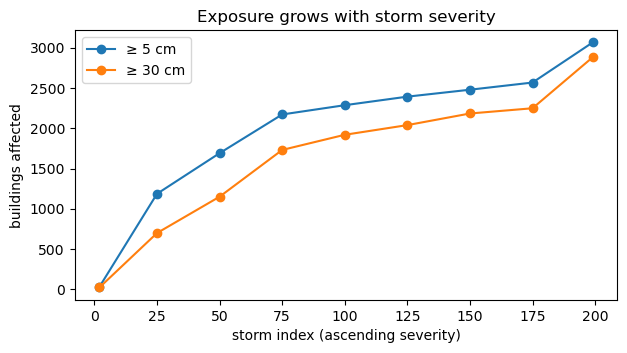

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(curve.index, curve["buildings >= 5 cm"], marker="o", label="≥ 5 cm")
ax.plot(curve.index, curve["buildings >= 30 cm"], marker="o", label="≥ 30 cm")
ax.set_xlabel("storm index (ascending severity)")
ax.set_ylabel("buildings affected")
ax.set_title("Exposure grows with storm severity")
ax.legend(); plt.show()

## 9. Mapping it

The dashboard draws the affected features as a map layer coloured by band. Here is
the same thing statically, over the depth raster.

/tmp/ipykernel_2042994/2409181579.py:13: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left", fontsize=8)


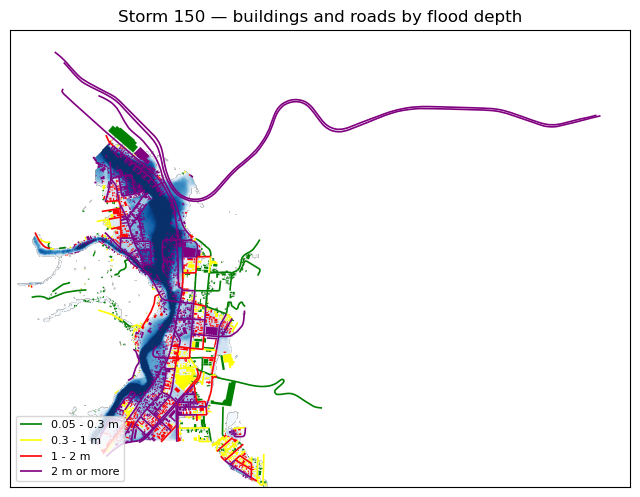

In [16]:
fig, ax = plt.subplots(figsize=(8, 7))
extent = rasterio.transform.array_bounds(rows, cols, zarr_transform)
ax.imshow(shown, cmap="Blues", vmin=0, vmax=6,
          extent=(extent[0], extent[2], extent[1], extent[3]))

for value, colour, _floor in DEPTH_BANDS:
    subset = features[features.band == value]
    if not subset.empty:
        subset.plot(ax=ax, color=colour, linewidth=1.2, label=BAND_LABEL[value])

ax.set_title(f"Storm {STORM} — buildings and roads by flood depth")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="lower left", fontsize=8)
plt.show()

Only features that reach a band are drawn. Dry ones are the large majority and
add nothing a basemap does not already show — dropping them also takes the map
layer's payload from about 2 MB down to a few hundred KB, which matters when it
re-fetches every time the slider moves.

## 10. How the dashboard plugin does it

The plugin is the same logic, arranged so TethysDash can call it. Two plugins
share one core:

| plugin | type | what it returns |
|---|---|---|
| `wmo_storm_impact_summary_en` / `_es` | `table` | the table from section 7 |
| `wmo_storm_impact_layer_en` / `_es` | `map_layer` | the features from section 9 |

The pieces worth pointing out:

- **The id grid is cached** (`@lru_cache`) because it does not depend on the storm.
  Section 5's rasterise happens once per process, not once per slider move.
- **The layer is a `dynamic_map_layer`** — it re-runs `fetch_features()` whenever
  the bound `Storm` variable changes, which is what makes the slider interactive.
- **Output CRS is EPSG:3857**, the store's own grid. OpenLayers resolves that
  natively, so nothing is reprojected on the way to the browser.
- **English and Spanish share this code.** Only the strings differ, and hazard
  levels and depth bands are keyed by their *numeric* class value, so a
  translation can never change a classification.

Run the cell below to read the real source, if the package is installed.

In [17]:
import inspect

try:
    from tgf_wmo_plugins import storm_impact
    source = inspect.getsource(storm_impact)
    print(source[: source.index("def classify_depth")])
except ImportError:
    print("tgf_wmo_plugins is not installed here.\n"
          "Install it with:  pip install -e .   from the repository root.")

"""Shared core for per-storm impact on buildings and roads.

The RainyDay ensemble and the IBF buildings/roads turn out to sit on exactly the
same grid -- EPSG:3857, 424x319, 5 m cells, identical origin -- so a storm's depth
raster can be sampled onto the features with no reprojection or resampling at all.

This answers a different question from `impact_summary`. That one reports exposure
against exceedance probabilities ("what are the odds of 30 cm here"); this reports
depth in one specific storm ("in storm 150, how deep at each building"). Depth is a
physical quantity, so a band needs no explanation the way a probability gate does.
"""

from functools import lru_cache

import geopandas as gpd
import numpy as np
import rasterio
from rasterio.features import rasterize
from shapely import set_precision

from tgf_wmo_plugins.common import DEFAULT_STORE, FEATURES_URL, open_zarr_store

# Ascending, so assigning in order lets the deepest band a feature reaches win --
# the same escalation c

### Things to try

- Change `STORM` in section 1 and re-run. Storm 2 is nearly dry; 199 is the worst
  in the ensemble.
- Change the `DEPTH_BANDS` bounds. What happens to the table if you add a
  `4 m or more` band?
- The population figures use `TOTAL_POPULATION` (every building) as the
  denominator. Recompute the percentages against only the 5,029 features inside
  the model domain. How much does the answer move?
- Section 5 takes the **maximum** depth over each footprint. Try the mean instead
  (`np.add.at` and a count) and see how the table changes. Which is the more
  defensible number to give a decision-maker?